# Validação da distribuição do rótulo de risco

Análise exploratória (sem novo código de produção) para documentar a % de VINs marcados `em_risco`, no total e por modelo, antes de seguir para o treino do modelo. Usa só as funções já implementadas e testadas em `src/infrastructure/xlsx_reader.py`, `src/application/build_vehicle_features.py` e `src/domain/risk_label.py`.

In [1]:
import sys
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from src.infrastructure.xlsx_reader import normalize_date_columns, remove_duplicate_service_orders, DATE_COLUMNS, DEDUP_SUBSET
from src.application.build_vehicle_features import (
    build_gap_relativo_table,
    compute_service_count_and_gap_std,
    compute_vehicle_age_days,
    compute_median_service_interval_by_model,
)
from src.domain.risk_label import compute_gap_com_fallback, compute_em_risco

RAW_PATH = "../data/raw/vin_share.zip"
REFERENCE_DATE = pd.Timestamp.now().normalize()
OUTPUT_PNG = "em_risco_por_modelo.png"

## 1. Reconstrói a pipeline de features (issues anteriores) e o rótulo `em_risco`

In [2]:
df = pd.read_csv(RAW_PATH, compression="zip", low_memory=False)
df, _ = normalize_date_columns(df, DATE_COLUMNS)
df, n_duplicatas = remove_duplicate_service_orders(df, DEDUP_SUBSET)

tabela = build_gap_relativo_table(df, reference_date=REFERENCE_DATE)

n_servicos = compute_service_count_and_gap_std(df)[["VIN_Hash", "n_servicos"]]
idade = compute_vehicle_age_days(
    df.groupby("VIN_Hash", as_index=False)[["SalesDate", "DeliveryDate"]].first(),
    reference_date=REFERENCE_DATE,
)[["VIN_Hash", "idade_dias"]]

tabela = tabela.merge(n_servicos, on="VIN_Hash", how="left").merge(idade, on="VIN_Hash", how="left")

intervalo_mediano_geral = compute_median_service_interval_by_model(df)["mediana_dias"].median()

tabela["gap_com_fallback"] = compute_gap_com_fallback(
    tabela["gap_relativo"],
    tabela["idade_dias"],
    tabela["intervalo_mediano_esperado"],
    tabela["n_servicos"],
    intervalo_mediano_geral=intervalo_mediano_geral,
)
tabela["em_risco"] = compute_em_risco(tabela["gap_com_fallback"])

print(f"Linhas de serviço (pós-dedup): {len(df):,} (duplicatas removidas: {n_duplicatas:,})")
print(f"VINs: {len(tabela):,}")
print(f"em_risco nulo: {tabela['em_risco'].isna().sum()}")

Linhas de serviço (pós-dedup): 535,821 (duplicatas removidas: 66,967)
VINs: 175,554
em_risco nulo: 0


## 2. % em risco no total

In [3]:
n_total = len(tabela)
n_em_risco = tabela["em_risco"].sum()
pct_em_risco_total = n_em_risco / n_total

print(f"Total de VINs: {n_total:,}")
print(f"Em risco: {n_em_risco:,} ({pct_em_risco_total:.1%})")
print(f"Não em risco: {n_total - n_em_risco:,} ({1 - pct_em_risco_total:.1%})")

Total de VINs: 175,554
Em risco: 145,165 (82.7%)
Não em risco: 30,389 (17.3%)


## 3. % em risco por modelo, com checagem de plausibilidade (nem 0%, nem 90%+)

In [4]:
por_modelo = (
    tabela.groupby("ModelName")["em_risco"]
    .agg(n_vins="count", n_em_risco="sum")
    .assign(pct_em_risco=lambda d: d["n_em_risco"] / d["n_vins"])
    .sort_values("pct_em_risco")
    .reset_index()
)

LIMITE_BAIXO = 0.0
LIMITE_ALTO = 0.90
por_modelo["plausivel"] = por_modelo["pct_em_risco"].between(LIMITE_BAIXO, LIMITE_ALTO, inclusive="neither")

pd.set_option("display.float_format", lambda x: f"{x:.1%}" if 0 <= x <= 1 else f"{x:,.2f}")
por_modelo

,ModelName,n_vins,n_em_risco,pct_em_risco,plausivel
0,BRONCO SPORT,5689,3471,61.0%,True
1,EDGE,92,59,64.1%,True
2,MAVERICK,5890,3909,66.4%,True
3,TERRITORY,11376,7598,66.8%,True
4,MUSTANG,1667,1118,67.1%,True
5,MUSTANG MACH-E,130,88,67.7%,True
6,F-150,1681,1160,69.0%,True
7,FUSION/MONDEO,11,8,72.7%,True
8,RANGER,78225,60340,77.1%,True
9,FOCUS,18,16,88.9%,True


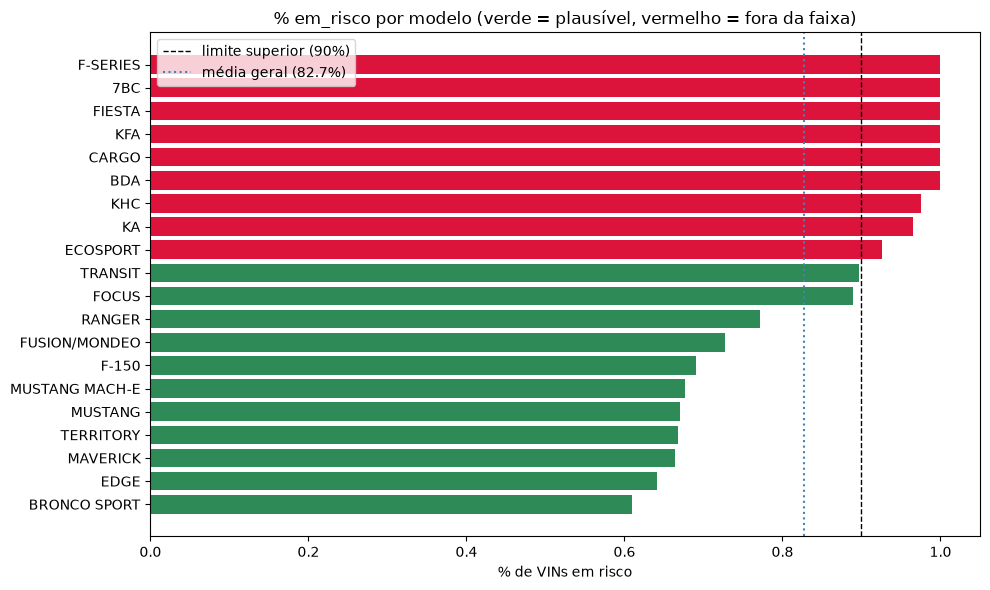

Gráfico salvo em: C:\Users\bruno\Desktop\challenge_next\ford-next\backend\notebooks\em_risco_por_modelo.png

Modelos fora da faixa plausível (nem 0%, nem 90%+):
ModelName  n_vins  n_em_risco  pct_em_risco  plausivel
 ECOSPORT   16010       14826         92.6%      False
       KA   50373       48609         96.5%      False
      KHC      80          78         97.5%      False
      BDA      14          14        100.0%      False
    CARGO     125         125        100.0%      False
      KFA      25          25        100.0%      False
   FIESTA       8           8        100.0%      False
      7BC       1           1        100.0%      False
 F-SERIES      17          17        100.0%      False


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

cores = ["seagreen" if ok else "crimson" for ok in por_modelo["plausivel"]]
ax.barh(por_modelo["ModelName"], por_modelo["pct_em_risco"], color=cores)
ax.axvline(LIMITE_ALTO, color="black", linestyle="--", linewidth=1, label=f"limite superior ({LIMITE_ALTO:.0%})")
ax.axvline(pct_em_risco_total, color="steelblue", linestyle=":", linewidth=1.5, label=f"média geral ({pct_em_risco_total:.1%})")

ax.set_xlabel("% de VINs em risco")
ax.set_title("% em_risco por modelo (verde = plausível, vermelho = fora da faixa)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_PNG, dpi=150)
plt.show()

print(f"Gráfico salvo em: {pathlib.Path(OUTPUT_PNG).resolve()}")
print()
modelos_implausiveis = por_modelo[~por_modelo["plausivel"]]
if len(modelos_implausiveis):
    print("Modelos fora da faixa plausível (nem 0%, nem 90%+):")
    print(modelos_implausiveis.to_string(index=False))
else:
    print("Nenhum modelo fora da faixa plausível (0% - 90%).")